mean price of 10000.209123137029
std of 4.858190724566338


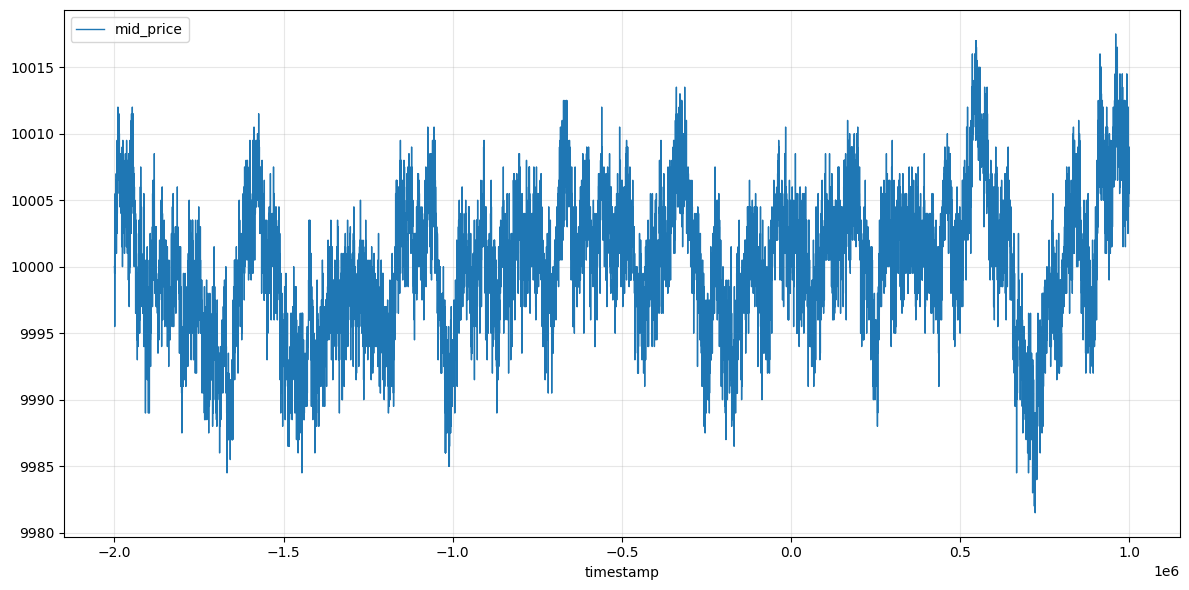

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string, json, math, statistics

from updated_tools import *

# hyperparamaters
PRODUCT = "ASH_COATED_OSMIUM"

df = extract_data(1, 20000)
df = df[df["product"] == PRODUCT]
df_filtered = df[(df['bid_price_1'].notna()) & (df['ask_price_1'].notna())]
# print(df_filtered)
print("mean price of", df_filtered["mid_price"].mean())
print("std of", df_filtered["mid_price"].std())
plot_mid_price(df_filtered)

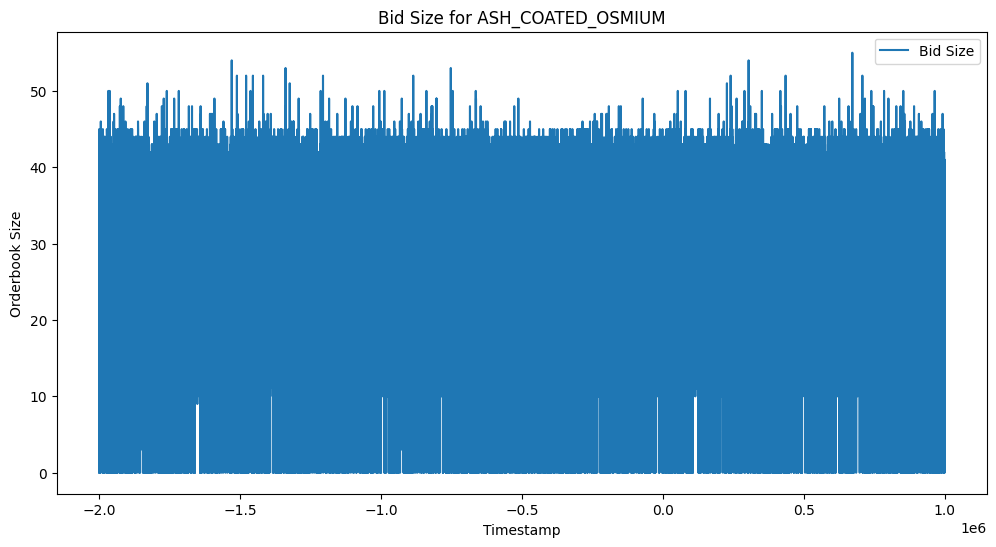

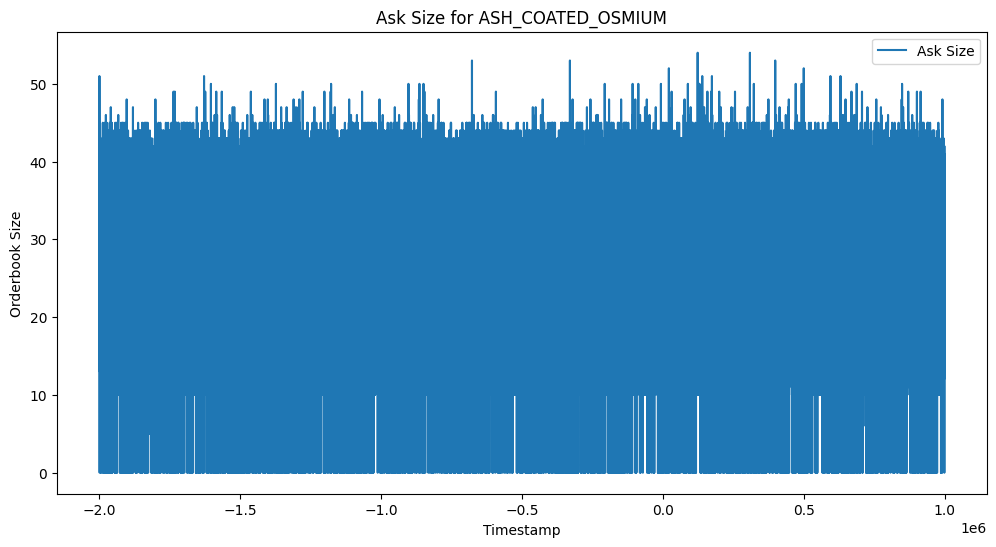

In [41]:
# determine orderbook size for product
plot_orderbook_buy_size(df, title = f"Bid Size for {PRODUCT}")
plot_orderbook_sell_size(df, title = f"Ask Size for {PRODUCT}")

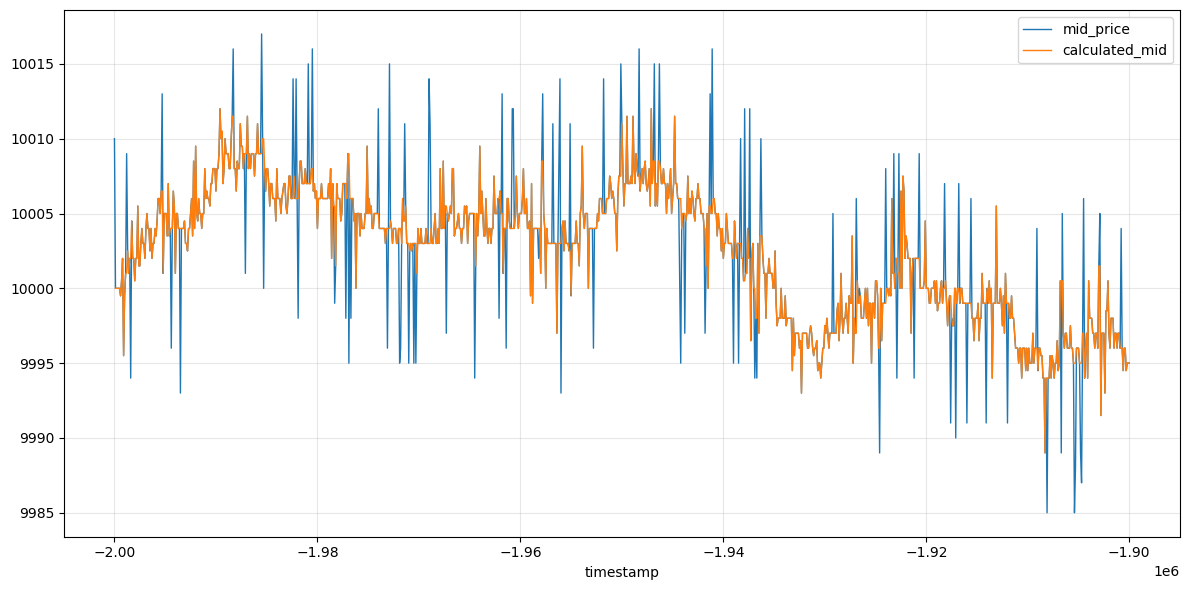

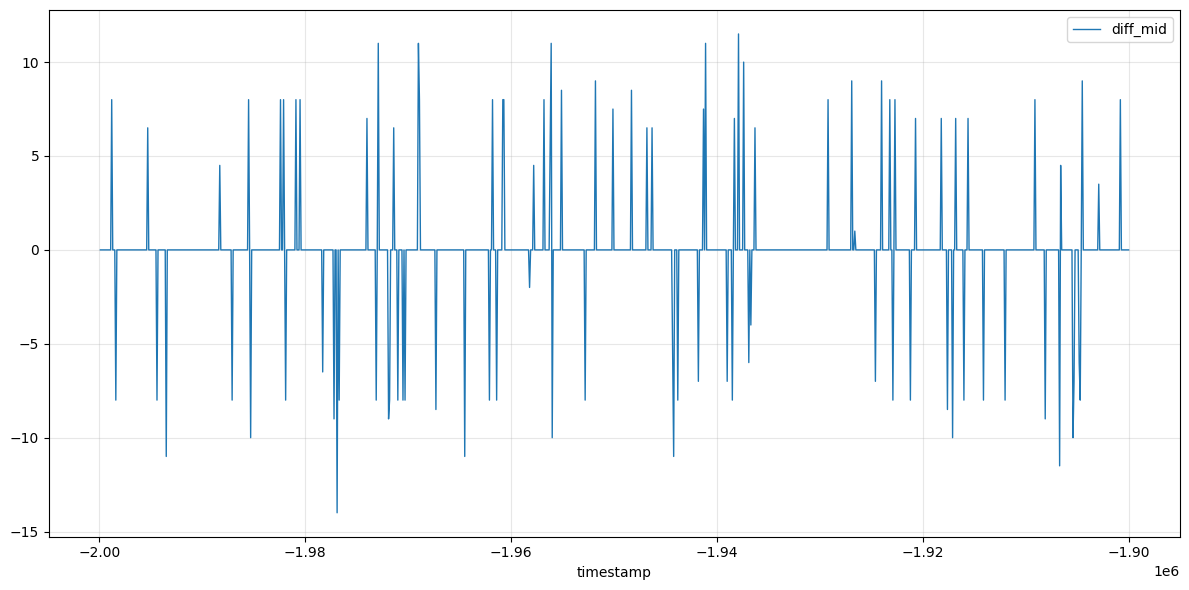

% of rows off by >= 1: 0.09018036072144289


In [42]:
# execute our strat; see what our calculated mid price looks like

# first, test on a sample of data
columns = ["mid_price", "calculated_mid"]
df_early = df[df["timestamp"] <= -1.9e6].copy()
df_early["calculated_mid"] = 0.5 * (df["best_bid"] + df["best_ask"])
df_early = df_early.ffill()
df_early = df_early[df_early["mid_price"] != 0]
plot_against_timestamp(df_early, columns)

# ^ plotting this is lowk useless... maybe plot difference?
df_early["diff_mid"] = df_early["mid_price"] - df_early["calculated_mid"]
plot_against_timestamp(df_early, ["diff_mid"])
df_false_nuke = df_early[df_early["diff_mid"] ** 2 >= 1]
off_percent = len(df_false_nuke) / len(df_early)
print(f"% of rows off by >= 1: {off_percent}")
df_false_nuke[["timestamp", "best_bid", "best_ask", "calculated_mid", "mid_price", "diff_mid"]].to_csv("r1_false_nuke.csv")

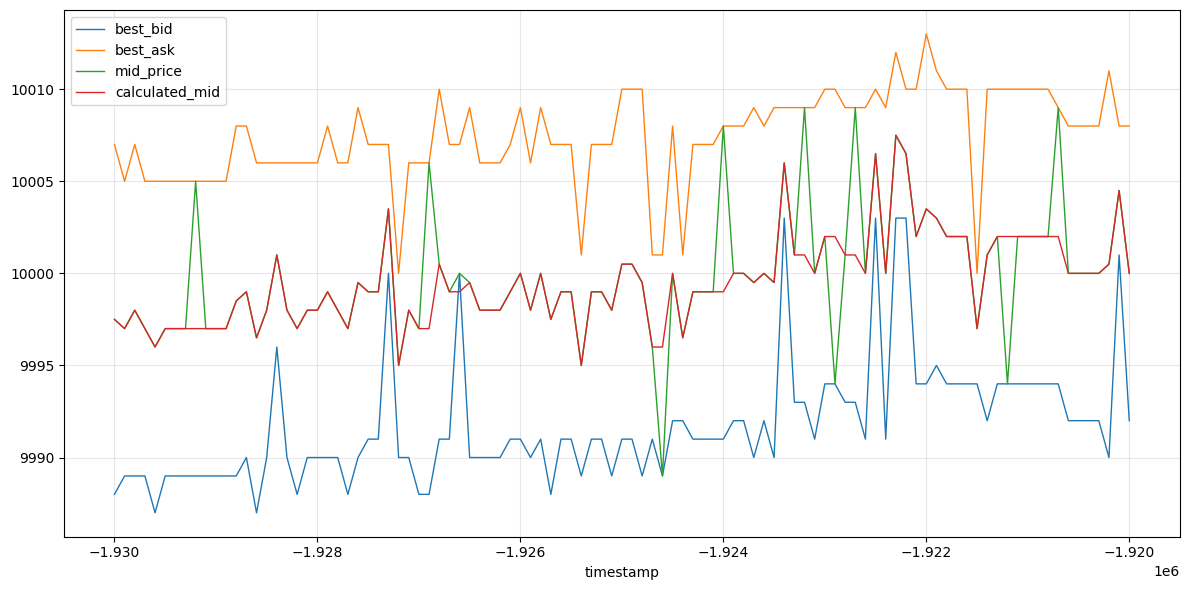

In [43]:
# isolate this spike; what's happening around it??
# ,timestamp,best_bid,best_ask,calculated_mid,mid_price,diff_mid
# 1416,-1929200,9989.0,10005.0,9997.0,10005.0,8.0

df_early_tester = df_early[(df_early["timestamp"] >= -1.93e6) & (df_early["timestamp"] <= -1.92e6)]
plot_against_timestamp(df_early_tester, ["best_bid", "best_ask", "mid_price", "calculated_mid"])
# ok nvm the mid price column is khose

the strat: 8.087613948777312


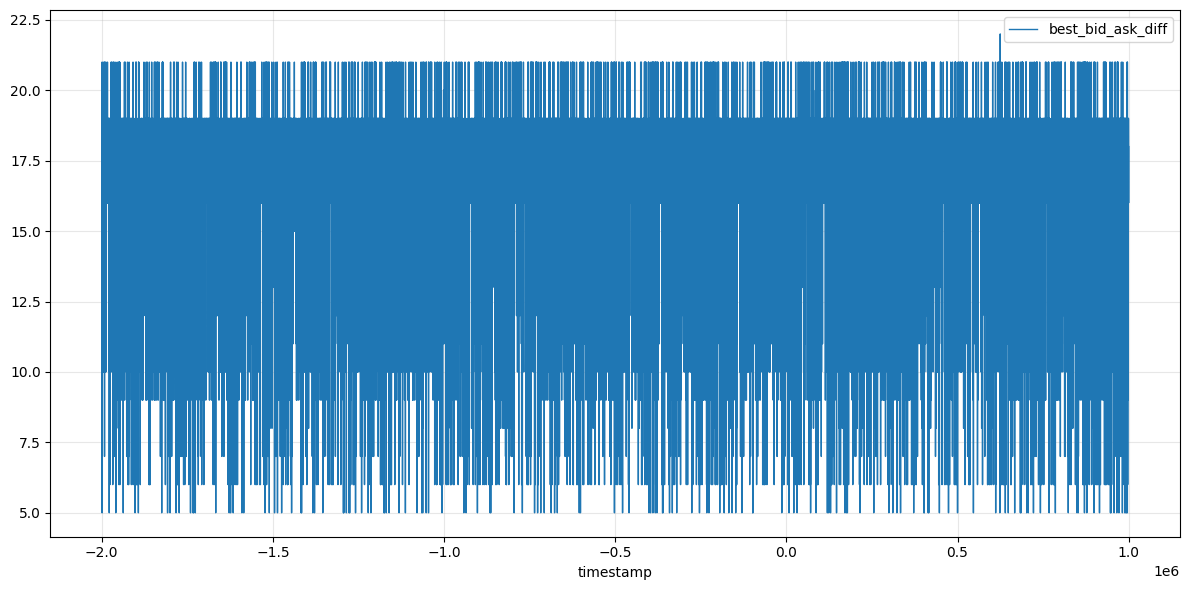

In [44]:
# figure out optimal spread

df_copy = df.copy()
df_copy = df_copy[(df_copy['bid_price_1'].notna()) & (df_copy['ask_price_1'].notna())]
df_copy["best_bid_ask_diff"] = df_copy["best_ask"] - df_copy["best_bid"]
print("the strat:", df_copy["best_bid_ask_diff"].mean() / 2)
plot_against_timestamp(df_copy, ["best_bid_ask_diff"])

# this gives... "the strat: 8.087613948777312"
# but we are using 7 to undercut them --> this is fine

In [45]:
# ANALYSIS of R1_ig1.py vs R1_daviiiiiiiis.py

import re

def extract_positions(file_path):
    positions = []
    pattern = re.compile(r"position:\s*(\d{1,3})")

    with open(file_path, 'r') as file:
        for line in file:
            matches = pattern.findall(line)
            for match in matches:
                num = int(match)
                if 0 <= num <= 100:
                    positions.append(num)

    return positions

def sum_of_squares(numbers):
    return sum(n**2 for n in numbers)

file_path_1 = r"C:\\Users\\ishaa\\Downloads\\IMC-Prosperity-4\\algo\\backtests\\2026-04-15_20-23-49.log" # davis
file_path_2 = r"C:\\Users\\ishaa\\Downloads\\IMC-Prosperity-4\\algo\\backtests\\2026-04-15_20-24-09.log" # ig1
print(f"Sum of squares for fp1 is {sum_of_squares(extract_positions(file_path_1))}")
print(f"Sum of squares for fp2 is {sum_of_squares(extract_positions(file_path_2))}")

Sum of squares for fp1 is 9436802
Sum of squares for fp2 is 63147


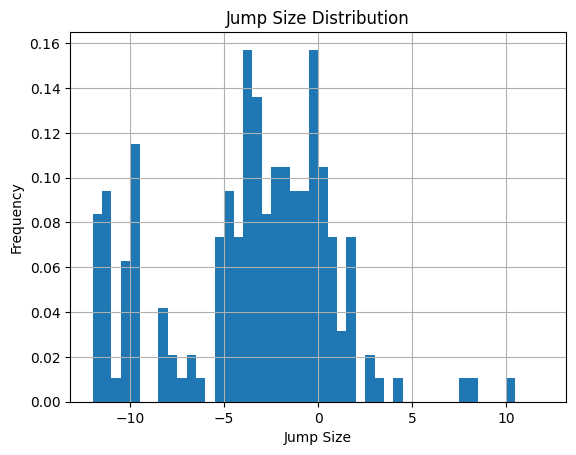

sanity check: 1.0
-12.0 -11.5 0.04188481675392671
-11.5 -11.0 0.04712041884816755
-11.0 -10.5 0.005235602094240839
-10.5 -10.0 0.03141361256544503
-10.0 -9.5 0.05759162303664923
-9.5 -9.0 0.0
-9.0 -8.5 0.0
-8.5 -8.0 0.020942408376963356
-8.0 -7.5 0.010471204188481678
-7.5 -7.0 0.005235602094240839
-7.0 -6.5 0.010471204188481678
-6.5 -6.0 0.005235602094240839
-6.0 -5.5 0.0
-5.5 -5.0 0.03664921465968587
-5.0 -4.5 0.04712041884816755
-4.5 -4.0 0.03664921465968587
-4.0 -3.5 0.07853403141361258
-3.5 -3.0 0.0680628272251309
-3.0 -2.5 0.04188481675392671
-2.5 -2.0 0.052356020942408384
-2.0 -1.5 0.052356020942408384
-1.5 -1.0 0.04712041884816755
-1.0 -0.5 0.04712041884816755
-0.5 0.0 0.07853403141361258
0.0 0.5 0.052356020942408384
0.5 1.0 0.03664921465968587
1.0 1.5 0.015706806282722516
1.5 2.0 0.03664921465968587
2.0 2.5 0.0
2.5 3.0 0.010471204188481678
3.0 3.5 0.005235602094240839
3.5 4.0 0.0
4.0 4.5 0.005235602094240839
4.5 5.0 0.0
5.0 5.5 0.0
5.5 6.0 0.0
6.0 6.5 0.0
6.5 7.0 0.0
7.0 7.5 0.

In [46]:
# analysis of R1_davis_final.py!!

# step 1: analyze the data to find what trends exist

'''
GETTING THE MID PRICE
'''

# get a copy of original data, get the scaled mid price (actual - line)
df_test = df.copy()
df_test["scaled_mid"] = df_test["mid_price"] - (12000 + df_test["timestamp"] / 1000)
# plot_against_timestamp(df_test, ["scaled_mid"])
scaled_mid_values = df_test["scaled_mid"].tolist()
# scaled_mid_mean = df_test["scaled_mid"].mean()
# print(f"Mean: {scaled_mid_mean}")

# plot this to get deviations
endpt = 12
bin_size = 0.5
bin_cnt = int(2 * endpt / bin_size)
bins = np.linspace(-endpt, endpt, bin_cnt + 1)
plt.figure()
plt.hist(scaled_mid_values, bins=bins, density=True)
plt.xlabel("Jump Size")
plt.ylabel("Frequency")
plt.title("Jump Size Distribution")
plt.grid(True)
plt.show()

# naively, we can copy the percentages of deviations and set them up in the same way
total_len = len(df_test)
start_vals = [-endpt + i * bin_size for i in range(bin_cnt)]
end_vals = [bin_size + x for x in start_vals]
deviations = [len(df_test[(df_test["scaled_mid"] >= start) & (df_test["scaled_mid"] < end)]) / total_len
              for start, end in zip(start_vals, end_vals)]
sum_of_dev = sum(deviations)
for i in range(len(deviations)):
    deviations[i] /= sum_of_dev # delete python's freaking ROUNDING ERROOOOOOOR
print("sanity check:", sum(deviations))
for i in range(len(deviations)):
    print(start_vals[i], end_vals[i], deviations[i])

In [47]:
'''
MODELLING THE BOTS
'''

# next step is to model bot behavior around the mid price

# for each price, plot price vs quantity
distributions = {}

for column in [str(i) for i in range(1, 4)]:
    for sign in ["bid", "ask"]:
        price_str = f"{sign}_price_{column}"
        volume_str = f"{sign}_volume_{column}"

        df_subset = df_test[df_test[price_str].notna()].copy()

        # x = volume, y = price relative to mid
        x = df_subset[volume_str].to_numpy()
        y = (df_subset[price_str] - df_subset["mid_price"]).to_numpy()

        # 2D histogram counts
        counts, xedges, yedges = np.histogram2d(x, y, bins=50)

        total_count = counts.sum()
        probs = counts / total_count if total_count > 0 else counts

        # Store everything for later use
        distributions[(sign, column)] = {
            "counts": counts,
            "probs": probs,
            "xedges": xedges,
            "yedges": yedges,
            "total_count": total_count,
        }

        # Optional: plot probability heatmap instead of raw counts
        # plt.figure()
        # plt.hist2d(x, y, bins=[xedges, yedges], weights=np.ones_like(x) / len(x))
        # plt.colorbar(label="Probability")
        # plt.xlabel("volume")
        # plt.ylabel("price - mid_price")
        # plt.title(f"{price_str} probability heatmap")
        # plt.show()

In [48]:
# get probabilities for having x bids, y asks

def compute(x: int, y: int):
    return len(df_test[(df_test["bid_price_" + str(x)].notna() if x > 0 else df_test["timestamp"].notna()) &
                       (df_test["ask_price_" + str(y)].notna() if y > 0 else df_test["timestamp"].notna())]) / len(df_test)

cumul_bid_ask = [[compute(x, y) for x in range(4)] for y in range(4)]
for i in range(4):
    cumul_bid_ask[i].append(0)
cumul_bid_ask.append([0 for _ in range(5)])
true_bid_ask = [[cumul_bid_ask[x][y] - cumul_bid_ask[x][y+1] - cumul_bid_ask[x+1][y] + cumul_bid_ask[x+1][y+1]
                for x in range(4)] for y in range(4)]
# print(cumul_bid_ask)
# print(true_bid_ask)
# print("sanity check:", sum([sum(true_bid_ask[i]) for i in range(4)])) 
# BIIIIG this is 1 as expected

# round because python is KHOOOOOOOSE
for x in range(4):
    for y in range(4):
        true_bid_ask[x][y] = round(true_bid_ask[x][y], 6)
total_sum = sum([sum(true_bid_ask[i]) for i in range(4)])
for x in range(4):
    for y in range(4):
        true_bid_ask[x][y] /= total_sum
print("sanity check:", sum([sum(true_bid_ask[i]) for i in range(4)]))

sanity check: 0.9999999999999999


In [49]:
# step 2: create a ton of new data

def generate_new_data_pepper_root() -> pd.DataFrame:
    df = pd.DataFrame(columns=["day","timestamp","product","bid_price_1","bid_volume_1","bid_price_2","bid_volume_2","bid_price_3","bid_volume_3","ask_price_1","ask_volume_1","ask_price_2","ask_volume_2","ask_price_3","ask_volume_3","mid_price","profit_and_loss"])

    # these columns are free
    df["day"] = [1 for _ in range(10000)]
    df["timestamp"] = list(range(0, 1000000, 100))
    df["product"] = "INTARIAN_PEPPER_ROOT"
    df["profit_and_loss"] = [0.0 for _ in range(10000)]

    # mid price
    df["mid_price"] = df["timestamp"] / 1000 + 13000
    # generate a list which has deviations w/ pmf from before
    first_random = np.random.choice(start_vals, size=10000, p=deviations)
    second_random = np.random.uniform(low=0, high=bin_size, size=10000)
    gen_deviations = (first_random + second_random).tolist() 
    df["mid_price"] += gen_deviations

    # find # of bids and asks; set a dict for str -> bool
    selected_bid_ask = {}
    flat_pmf = np.array(true_bid_ask).ravel()
    idx = np.random.choice(len(flat_pmf), size=len(df), p=flat_pmf)
    x, y = np.unravel_index(idx, np.array(true_bid_ask).shape)
    for column in [str(i) for i in range(1, 4)]:
        for sign in ["bid", "ask"]:
            mask = (x >= int(column)) if sign == "bid" else (y >= int(column))
            price_str = sign + "_price_" + column
            volume_str = sign + "_volume_" + column

            dist = distributions[(sign, column)]
            flat_pmf = dist["probs"].ravel()
            flat_idx = np.random.choice(flat_pmf.size, size=len(df), p=flat_pmf)
            vol_idx, price_idx = np.unravel_index(flat_idx, dist["probs"].shape)

            vol_val = 0.5 * (dist["xedges"][vol_idx] + dist["xedges"][vol_idx + 1])
            price_offset = 0.5 * (dist["yedges"][price_idx] + dist["yedges"][price_idx + 1])

            df.loc[mask, price_str] = df.loc[mask, "mid_price"].to_numpy() + price_offset[mask]
            df.loc[mask, volume_str] = vol_val[mask]
            df.loc[~mask, [price_str, volume_str]] = math.nan

    # round stuff to nearest int
    for column in [str(i) for i in range(1, 4)]:
        for sign in ["bid", "ask"]:
            price_str = sign + "_price_" + column
            volume_str = sign + "_volume_" + column
            df[price_str] = df[price_str].astype(float).round().astype('Int64')
            df[volume_str] = df[volume_str].astype(float).round().astype('Int64')
    df["mid_price"] = df["mid_price"].astype(float).round().astype('Int64')

    return df

In [50]:
def generate_trades_file_pepper_root() -> pd.DataFrame:
    """
    Generate a trades file for INTARIAN_PEPPER_ROOT and save it as CSV.

    Output columns:
    timestamp;buyer;seller;symbol;currency;price;quantity
    """
    rng = np.random.default_rng()

    rows = []

    for timestamp in range(0, 1_000_000, 100):
        # 3.32% chance of a matched trade at this timestamp
        if rng.random() < 0.0332:
            # Same price construction as before:
            # mid_price = timestamp / 1000 + 13000 + deviation
            first_random = rng.choice(start_vals, p=deviations)
            second_random = rng.uniform(0, bin_size)
            mid_price = (timestamp / 1000) + 13000 + first_random + second_random
            mid_price = round(mid_price)

            matched_price = float(mid_price + rng.integers(-8, 9))
            matched_volume = int(rng.integers(2, 11))

            rows.append({
                "timestamp": timestamp,
                "buyer": "",
                "seller": "",
                "symbol": "INTARIAN_PEPPER_ROOT",
                "currency": "XIRECS",
                "price": matched_price,
                "quantity": matched_volume,
            })

    trades_df = pd.DataFrame(
        rows,
        columns=["timestamp", "buyer", "seller", "symbol", "currency", "price", "quantity"]
    )

    trades_df["price"] = trades_df["price"].astype('Int64')
    trades_df["quantity"] = trades_df["quantity"].astype('Int64')

    return trades_df

In [65]:
# step 3: run both strategies on the new datasets

import os
import subprocess
import pandas as pd

def run_pnl_simulation(script_path: str, iterations: int):
    """
    Runs backtests multiple times and returns sorted PnLs.

    Parameters
    ----------
    script_path : str
        Path to the strategy file to run with prosperity4bt
    iterations : int
        Number of simulations

    Returns
    -------
    list[float]
        Sorted PnLs (ascending)
    """

    pnl_list = []

    data_dir = "C:\\Users\\ishaa\\Downloads\\IMC-Prosperity-4\\algo_exploration\\backtest_data"
    round1_dir = os.path.join(data_dir, "round1")

    os.makedirs(round1_dir, exist_ok=True)

    script_name = os.path.basename(script_path)

    for _ in range(iterations):
        # 1) generate data
        orderbook_df = generate_new_data_pepper_root()
        trades_df = generate_trades_file_pepper_root()

        # save to required directory
        orderbook_df.to_csv(
            os.path.join(round1_dir, "prices_round_1_day_0.csv"),
            sep=';',
            index=False
        )
        trades_df.to_csv(
            os.path.join(round1_dir, "trades_round_1_day_0.csv"),
            sep=";",
            index=False
        )

        # 2) run backtest command
        cmd = [
            "py", "-3.12", "-m", "prosperity4bt",
            script_name,
            "1",
            "--no-out",
            "--data", data_dir
        ]
        # print(" ".join(cmd))

        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            encoding="utf-8",
            errors="replace"
        )

        output = (result.stdout or "")
        output_lines = [line for line in output.splitlines() if line.strip()]

        # DEBUG
        # print("CMD:", " ".join(cmd))
        # print("STDOUT:\n", result.stdout or "")
        # print("STDERR:\n", result.stderr or "")
        # print("RETURN CODE:", result.returncode)

        if not output_lines:
            raise RuntimeError(f"No output from backtest:\n{result.stderr}")

        last_line = output_lines[-1].strip()
        given_str = last_line.split()[-1]
        assert(len(given_str) == 6)
        pnl = float(given_str[0:2] + given_str[3:])

        pnl_list.append(pnl)

    # 4) return sorted PnLs
    return sorted(pnl_list)

In [ ]:
# step 4: do a paired t-test to determine if one makes significantly more money than the other

pnl_list_ig = run_pnl_simulation("R1_temp_ig.py", 30)
pnl_list_davis = run_pnl_simulation("R1_temp_davis.py", 30)
print(pnl_list_ig)
print(f"mean of {np.array(pnl_list_ig).mean()}, std of {np.array(pnl_list_ig).std()}")
print(pnl_list_davis)
print(f"mean of {np.array(pnl_list_davis).mean()}, std of {np.array(pnl_list_davis).std()}")
# p-value of ~0.53 --> just pick the safer strat

[77338.0, 77399.0, 77474.0, 77515.0, 77559.0, 77609.0, 77631.0, 77638.0, 77652.0, 77676.0, 77676.0, 77797.0, 77813.0, 77857.0, 77939.0, 77967.0, 77994.0, 77994.0, 78017.0, 78035.0, 78059.0, 78062.0, 78099.0, 78116.0, 78172.0, 78209.0, 78218.0, 78336.0, 78363.0, 78604.0]
mean of 77893.93333333333, std of 304.59480552950265
[77116.0, 77219.0, 77268.0, 77591.0, 77777.0, 77807.0, 77942.0, 77987.0, 78043.0, 78072.0, 78104.0, 78182.0, 78184.0, 78258.0, 78421.0, 78445.0, 78454.0, 78475.0, 78497.0, 78509.0, 78552.0, 78600.0, 78615.0, 78616.0, 78616.0, 78762.0, 78762.0, 78841.0, 78992.0, 79269.0]
mean of 78265.86666666667, std of 509.6994364873828
